In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Чтение данных
df_orig = pd.read_csv('kvartiras.csv')
df = df_orig

df

,Кол-во комнат,"Площадь, м^2",Этаж квартиры,Кол-во этажей в доме,Относительный этаж,"Расстояние до центра, км",Ближайшая станция метро,"Расстояние до ближайшей станции метро, км","Балкон/Лоджия (1, 2)",Чистовая отделка,Проверено в Росреестре,От зайстройщика,Цена
0,1,37.2,15,24,0.625000,6.204222,Горки,3.154380,0,0,0,1,9008356
1,1,40.6,1,3,0.333333,19.270580,Кремлёвская,18.978129,2,0,0,1,4990863
2,1,43.0,4,9,0.444444,3.462537,Аметьево,1.082124,0,0,0,0,11899000
3,1,29.9,12,17,0.705882,1.951753,Суконная слобода,0.534792,0,0,0,1,15234000
4,1,35.6,21,25,0.840000,8.833398,Дубравная,3.261356,0,0,0,0,8685000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20095,студия,19.0,1,9,0.111111,7.494507,Проспект Победы,1.848302,0,0,0,0,3650000
20096,студия,31.5,15,26,0.576923,6.341970,Горки,2.202330,0,0,0,1,10330000
20097,студия,29.0,1,9,0.111111,1.946977,Суконная слобода,0.747920,0,0,0,0,5200000
20098,студия,15.8,6,9,0.666667,10.587873,Авиастроительная,9.167562,0,0,1,0,2800000


In [3]:
# Количество дубликатов в датасете
print(df.duplicated().sum())

# Удаление дубликатов
df = df.drop_duplicates()

11174


--- АНАЛИЗ ТИПОВ ДАННЫХ ---
Числовые признаки (11): ['Площадь, м^2', 'Этаж квартиры', 'Кол-во этажей в доме', 'Относительный этаж', 'Расстояние до центра, км', 'Расстояние до ближайшей станции метро, км', 'Балкон/Лоджия (1, 2)', 'Чистовая отделка', 'Проверено в Росреестре', 'От зайстройщика', 'Цена']
Категориальные признаки (2): ['Кол-во комнат', 'Ближайшая станция метро']

--- КАТЕГОРИАЛЬНЫХ ПРИЗНАКИ (Уникальные значения) ---
Признак 'Кол-во комнат': 7 уникальных значений
Кол-во комнат
2         2841
1         2785
3         2520
4          392
студия     383
Name: count, dtype: int64
------------------------------
Признак 'Ближайшая станция метро': 11 уникальных значений
Ближайшая станция метро
Горки               1783
Дубравная           1547
Козья слобода       1197
Аметьево            1036
Суконная слобода     922
Name: count, dtype: int64
------------------------------

--- СТАТИСТИКА ВЫБРОСОВ (IQR коэффициент = 4) ---
Признак 'Площадь, м^2':
  -> Граница нормы: до 211.00
  -> Ма

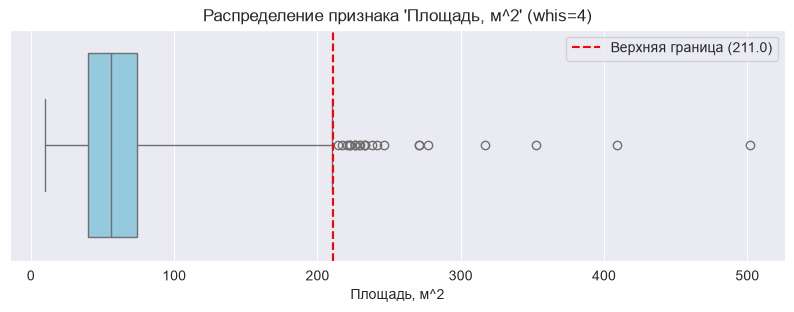

Признак 'Расстояние до центра, км':
  -> Граница нормы: до 25.76
  -> Максимальное значение в датасете: 28.949862848834957
  -> Будет удалено строк: 3 (из 8926)


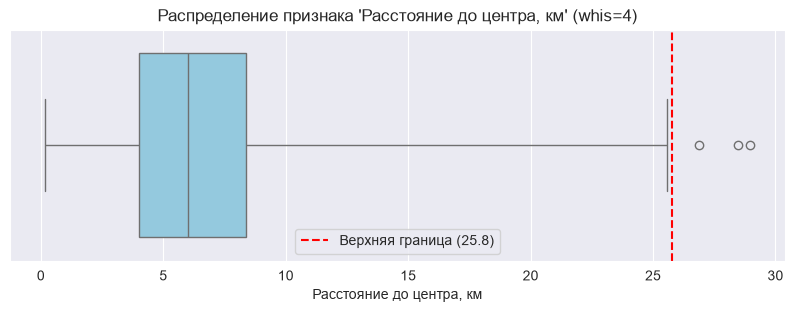

Признак 'Расстояние до ближайшей станции метро, км':
  -> Граница нормы: до 18.05
  -> Максимальное значение в датасете: 28.870695251071307
  -> Будет удалено строк: 131 (из 8926)


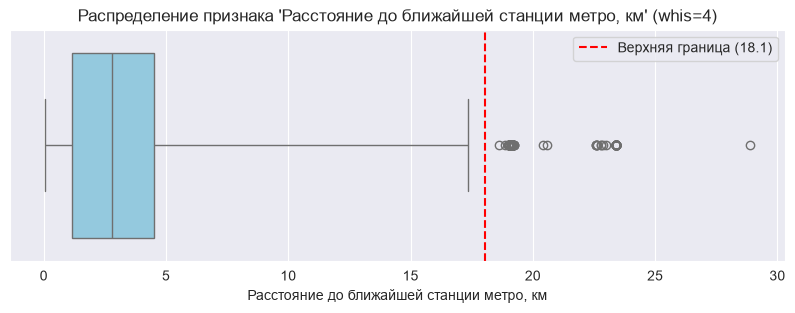

Признак 'Цена':
  -> Граница нормы: до 47600000.00
  -> Максимальное значение в датасете: 260000000
  -> Будет удалено строк: 140 (из 8926)


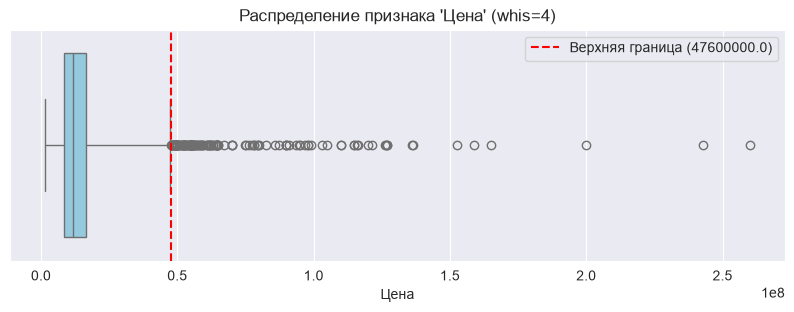

Признак 'Цена':
  -> Граница нормы: до 47600000.00
  -> Максимальное значение в датасете: 260000000
  -> Будет удалено строк: 140 (из 8926)


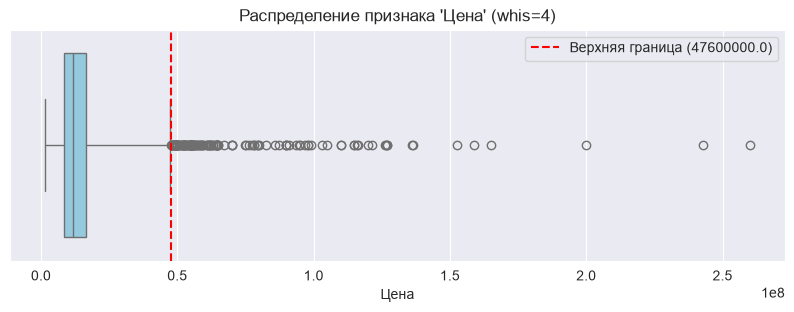

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. АВТОМАТИЧЕСКОЕ РАЗДЕЛЕНИЕ ПРИЗНАКОВ
# ==========================================

# Числовые признаки (все, где содержатся числа)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Категориальные признаки (текст, строки, объекты)
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print("--- АНАЛИЗ ТИПОВ ДАННЫХ ---")
print(f"Числовые признаки ({len(numerical_cols)}): {numerical_cols}")
print(f"Категориальные признаки ({len(categorical_cols)}): {categorical_cols}\n")

# ==========================================
# 2. РАССМОТРЕНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# ==========================================
print("--- КАТЕГОРИАЛЬНЫХ ПРИЗНАКИ (Уникальные значения) ---")
for col in categorical_cols:
    uniq_count = df[col].nunique()
    print(f"Признак '{col}': {uniq_count} уникальных значений")
    # Если уникальных значений немного, выведем топ-5 популярных
    if uniq_count <= 20:
        print(df[col].value_counts().head(5))
    print("-" * 30)

# ==========================================
# 3. ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ ДЛЯ ЧИСЛОВЫХ ПРИЗНАКОВ (С НАСТРОЙКОЙ IQR)
# ==========================================
iqr_coefficient = 4

print(f"\n--- СТАТИСТИКА ВЫБРОСОВ (IQR коэффициент = {iqr_coefficient}) ---")

# Замени названия в списке ниже на точные названия колонок из твоего df
cols_to_visualize = ['Площадь, м^2', 'Расстояние до центра, км', 'Расстояние до ближайшей станции метро, км', 'Цена']
if 'Цена' in numerical_cols:
    cols_to_visualize.append('Цена')

for col in cols_to_visualize:
    if col in df.columns:
        # Считаем квартили
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Определяем границы
        lower_bound = Q1 - iqr_coefficient * IQR
        upper_bound = Q3 + iqr_coefficient * IQR

        # Считаем сколько строк вылетает за верхнюю границу
        outliers_count = df[df[col] > upper_bound].shape[0]
        max_val = df[col].max()

        print(f"Признак '{col}':")
        print(f"  -> Граница нормы: до {upper_bound:.2f}")
        print(f"  -> Максимальное значение в датасете: {max_val}")
        print(f"  -> Будет удалено строк: {outliers_count} (из {len(df)})")

        # ИСПРАВЛЕНО: используем whis вместо whisper
        plt.figure(figsize=(10, 3))
        sns.boxplot(x=df[col], whis=iqr_coefficient, color='skyblue')
        plt.title(f"Распределение признака '{col}' (whis={iqr_coefficient})")
        plt.axvline(x=upper_bound, color='red', linestyle='--', label=f'Верхняя граница ({upper_bound:.1f})')
        plt.legend()
        plt.show()

In [5]:
# Задаем коэффициенты для каждого признака индивидуально
# Для площади ставим побольше (например, 4.5), чтобы усы дотянулись до ~300 м^2
coef_area = 4.5
coef_dist = 3.0
coef_price = 4.5  # тоже сделаем чуть повыше для элитных цен

def get_upper_bound(series, coef):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q3 + coef * iqr

# Считаем персональные верхние границы
max_area = get_upper_bound(df['Площадь, м^2'], coef_area)
max_dist = get_upper_bound(df['Расстояние до центра, км'], coef_dist)

print("--- РАССЧИТАННЫЕ ГРАНИЦЫ ---")
print(f"Максимальная площадь (норма): до {max_area:.1f} м^2")
print(f"Максимальное расстояние: до {max_dist:.1f} км")


# Если в датасете есть колонка с ценой (проверь точное название, например 'Цена, руб' или 'Цена')
price_col = 'Цена' # поменяй на свое название, если надо
if price_col in df.columns:
    max_price = get_upper_bound(df[price_col], coef_price)
    print(f"Максимальная цена: до {max_price:.1f}")
else:
    max_price = None

# Делаем фильтрацию
df_cleaned = df[
    (df['Площадь, м^2'] <= max_area) &
    (df['Расстояние до центра, км'] <= max_dist)
].copy()

if max_price is not None:
    df_cleaned = df_cleaned[df_cleaned[price_col] <= max_price]

print("\n--- ИТОГ ОЧИСТКИ ---")
print(f"Было строк: {df.shape[0]}")
print(f"Осталось качественных строк: {df_cleaned.shape[0]}")
print(f"Удалено экстремальных выбросов: {df.shape[0] - df_cleaned.shape[0]}")

# Перезаписываем наш рабочий датасет
df = df_cleaned.reset_index(drop=True)

--- РАССЧИТАННЫЕ ГРАНИЦЫ ---
Максимальная площадь (норма): до 228.1 м^2
Максимальное расстояние: до 21.4 км
Максимальная цена: до 51500000.0

--- ИТОГ ОЧИСТКИ ---
Было строк: 8926
Осталось качественных строк: 8682
Удалено экстремальных выбросов: 244


--- Построение распределений для непрерывных числовых признаков ---


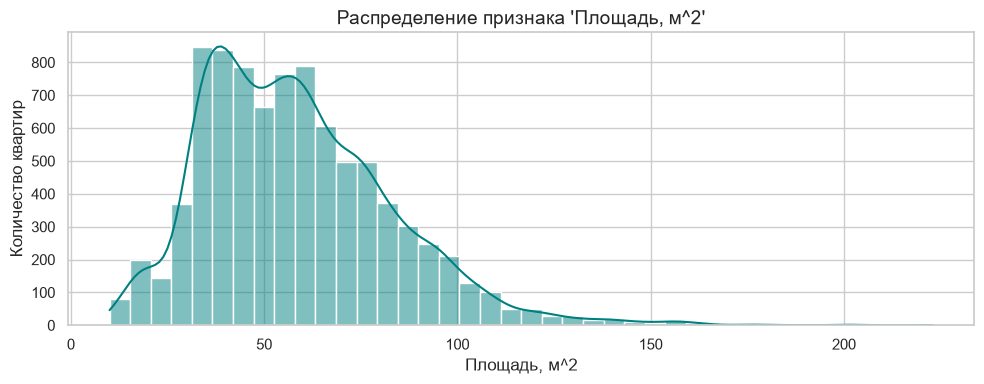

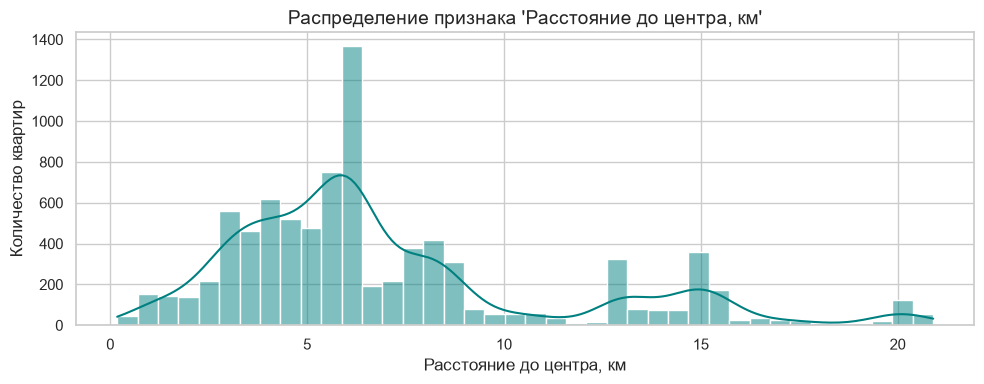

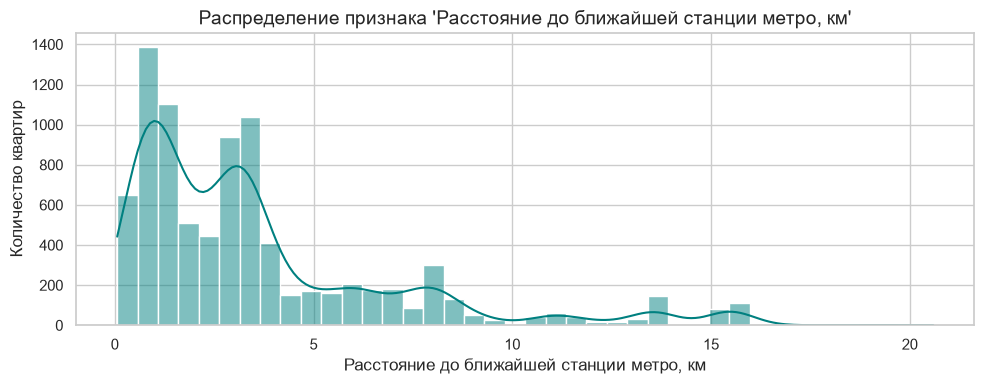

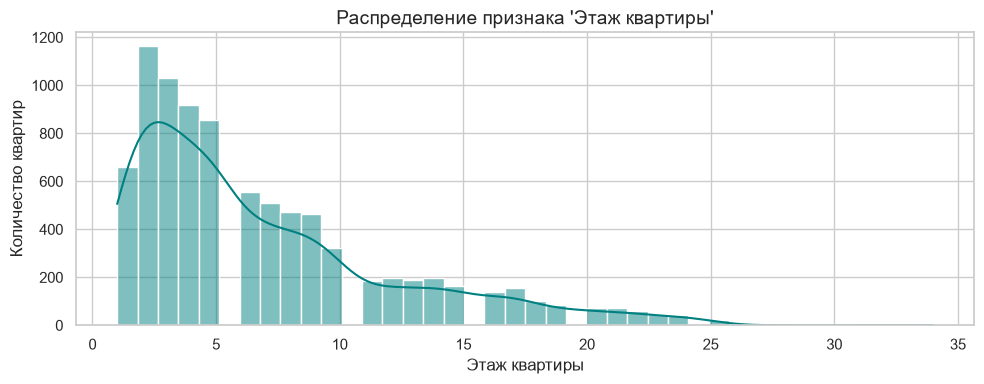

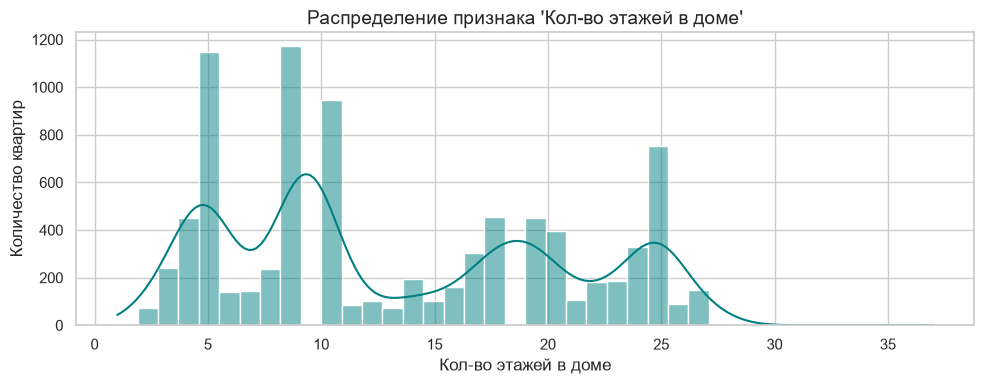

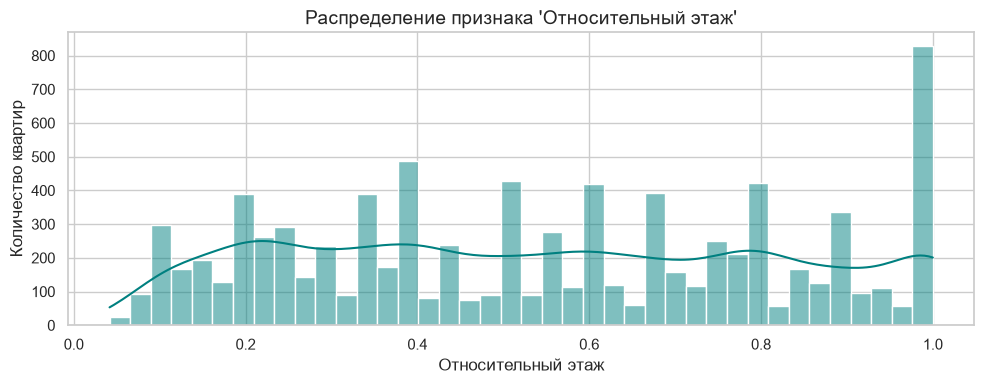

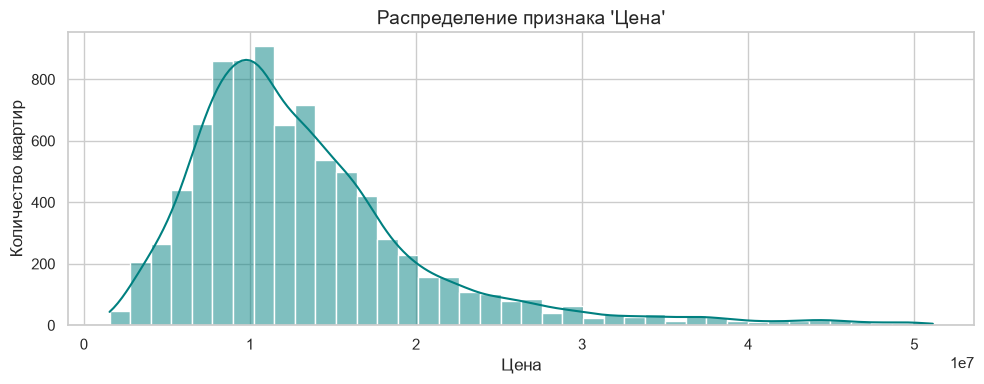


--- Построение частотных диаграмм для категориальных/дискретных признаков ---


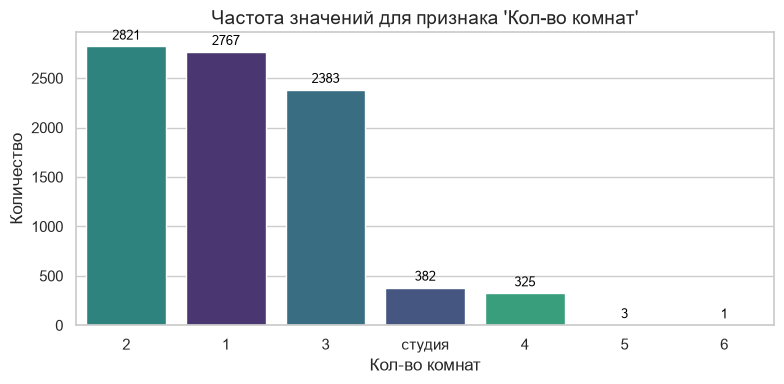

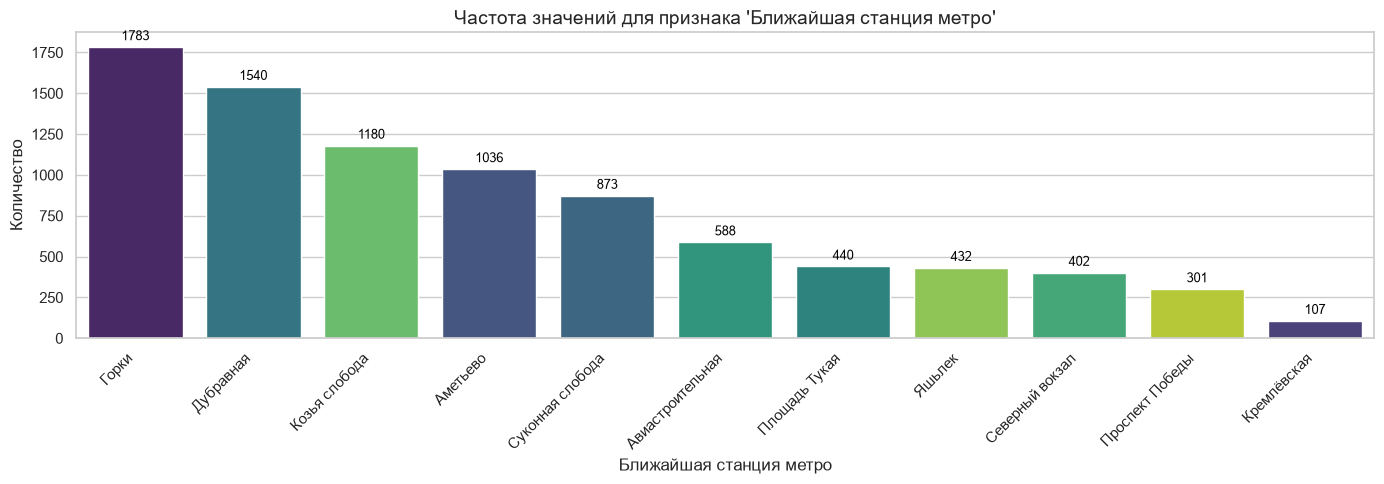

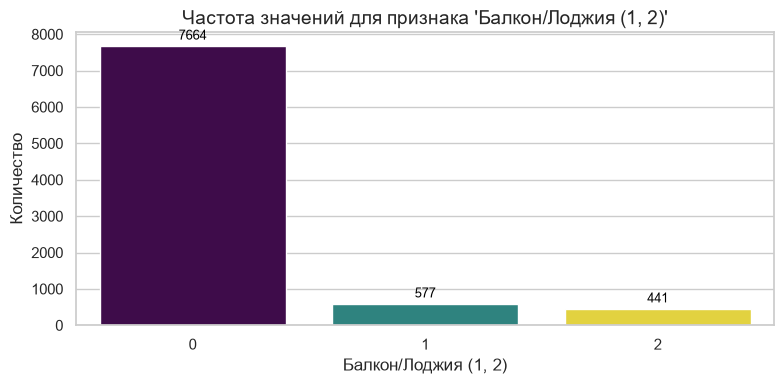

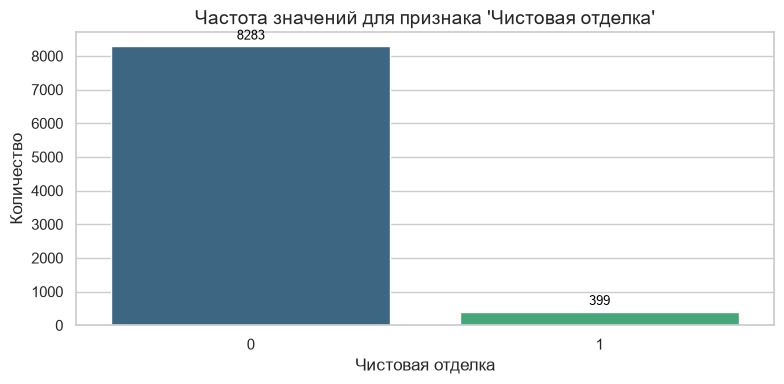

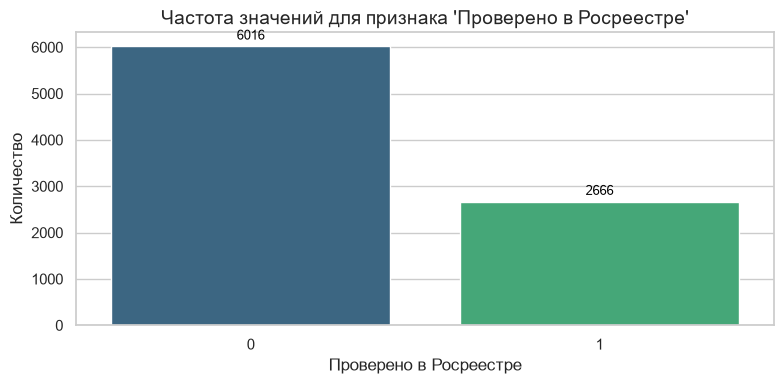

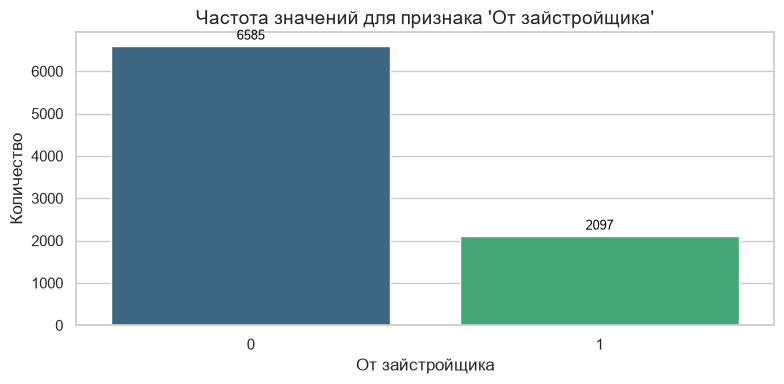

In [6]:
# Анализ распределения данных

# Установим красивый стиль для графиков
sns.set_theme(style="whitegrid")

# ==========================================
# 1. НЕПРЕРЫВНЫЕ ЧИСЛОВЫЕ ПРИЗНАКИ (Гистограммы)
# ==========================================
continuous_features = [
    'Площадь, м^2',
    'Расстояние до центра, км',
    'Расстояние до ближайшей станции метро, км',
    'Этаж квартиры',
    'Кол-во этажей в доме',
    'Относительный этаж',
    'Цена'
]

print("--- Построение распределений для непрерывных числовых признаков ---")
for col in continuous_features:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        # Строим гистограмму с линией плотности
        sns.histplot(df[col], kde=True, color='teal', bins=40)
        plt.title(f"Распределение признака '{col}'", fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel("Количество квартир", fontsize=12)
        plt.tight_layout()
        plt.show()

# ==========================================
# 2. КАТЕГОРИАЛЬНЫЕ И ДИСКРЕТНЫЕ ПРИЗНАКИ (Столбчатые диаграммы)
# ==========================================
categorical_and_discrete = [
    'Кол-во комнат',
    'Ближайшая станция метро',
    'Балкон/Лоджия (1, 2)',
    'Чистовая отделка',
    'Проверено в Росреестре',
    'От зайстройщика'
]

print("\n--- Построение частотных диаграмм для категориальных/дискретных признаков ---")
for col in categorical_and_discrete:
    if col in df.columns:
        # Если это метро или этажи (много уникальных значений), сделаем график пошире
        is_large = df[col].nunique() > 10
        plt.figure(figsize=(14, 5) if is_large else (8, 4))

        # Считаем порядок столбцов от самых популярных к менее популярным
        order = df[col].value_counts().index

        # Строим столбчатую диаграмму
        ax = sns.countplot(data=df, x=col, order=order, hue=col, legend=False, palette='viridis')
        plt.title(f"Частота значений для признака '{col}'", fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel("Количество", fontsize=12)

        # Если это метро, развернем названия станций, чтобы они не накладывались друг на друга
        if col == 'Ближайшая станция метро' or is_large:
            plt.xticks(rotation=45, ha='right')

        # Добавим подписи с точным количеством над каждым столбиком для презентабельности
        for p in ax.patches:
            height = p.get_height()
            if height > 0: # Проверка на случай пустых категорий
                ax.annotate(f'{int(height)}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                            textcoords='offset points')

        plt.tight_layout()
        plt.show()

**Исходя из графиков видно, что числовые признаки имеют положительную асимметрию (длинный правый хвост) и что многокомнатных квартир критический мало. Решением для данных проблем будет логарифмирование признаков и объединение редких групп в одну группу**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Копируем датасет для преобразований
df_encoded = df.copy()

# 1. Группируем редкие комнаты (все что >= 4 комнат делаем одной категорией '4+')
def group_rooms(room):
    if room in ['5', '6', '7', 4.0, 5.0, 6.0, 7.0, '4']:
        return '4+'
    return str(room)

df_encoded['Кол-во комнат'] = df_encoded['Кол-во комнат'].apply(group_rooms)

# 2. Создаем логарифмированные признаки для анализа корреляции
df_encoded['Log_Цена'] = np.log1p(df_encoded['Цена'])
df_encoded['Log_Площадь'] = np.log1p(df_encoded['Площадь, м^2'])

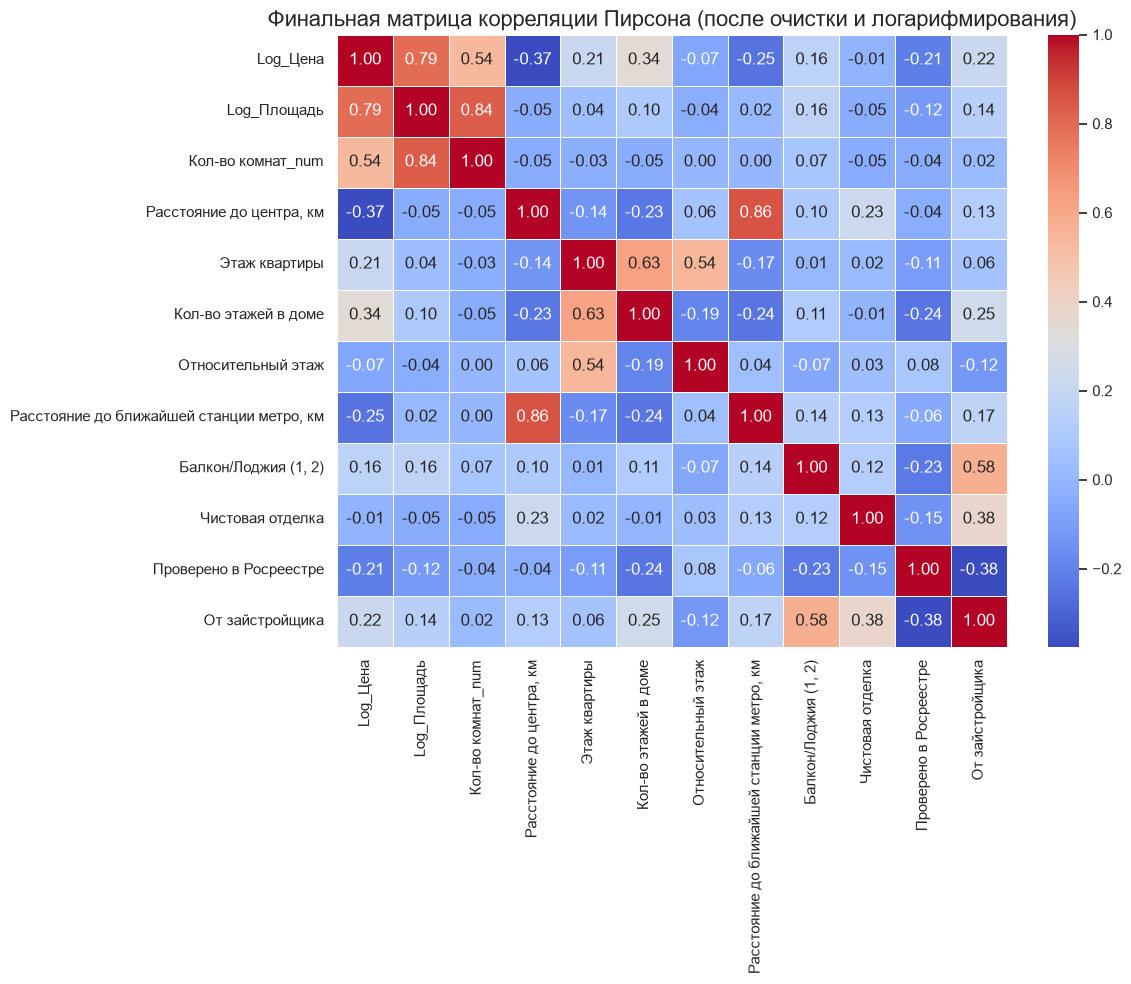

In [8]:
# ЛИНЕЙНАЯ корреляция Пирсона

# Отбираем числовые признаки для матрицы корреляции
room_mapping = {'Студия': 0, '1': 1, '2': 2, '3': 3, '4+': 4}
df_encoded['Кол-во комнат_num'] = df_encoded['Кол-во комнат'].map(room_mapping)

corr_cols = [
    'Log_Цена', 'Log_Площадь', 'Кол-во комнат_num' ,'Расстояние до центра, км',
    'Этаж квартиры', 'Кол-во этажей в доме', 'Относительный этаж',
    'Расстояние до ближайшей станции метро, км', 'Балкон/Лоджия (1, 2)',
    'Чистовая отделка', 'Проверено в Росреестре', 'От зайстройщика'
]

# Считаем матрицу корреляции Пирсона
corr_matrix_pearson = df_encoded[corr_cols].corr()

# Строим красивый Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_pearson, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Финальная матрица корреляции Пирсона (после очистки и логарифмирования)", fontsize=16)
plt.tight_layout()
plt.show()

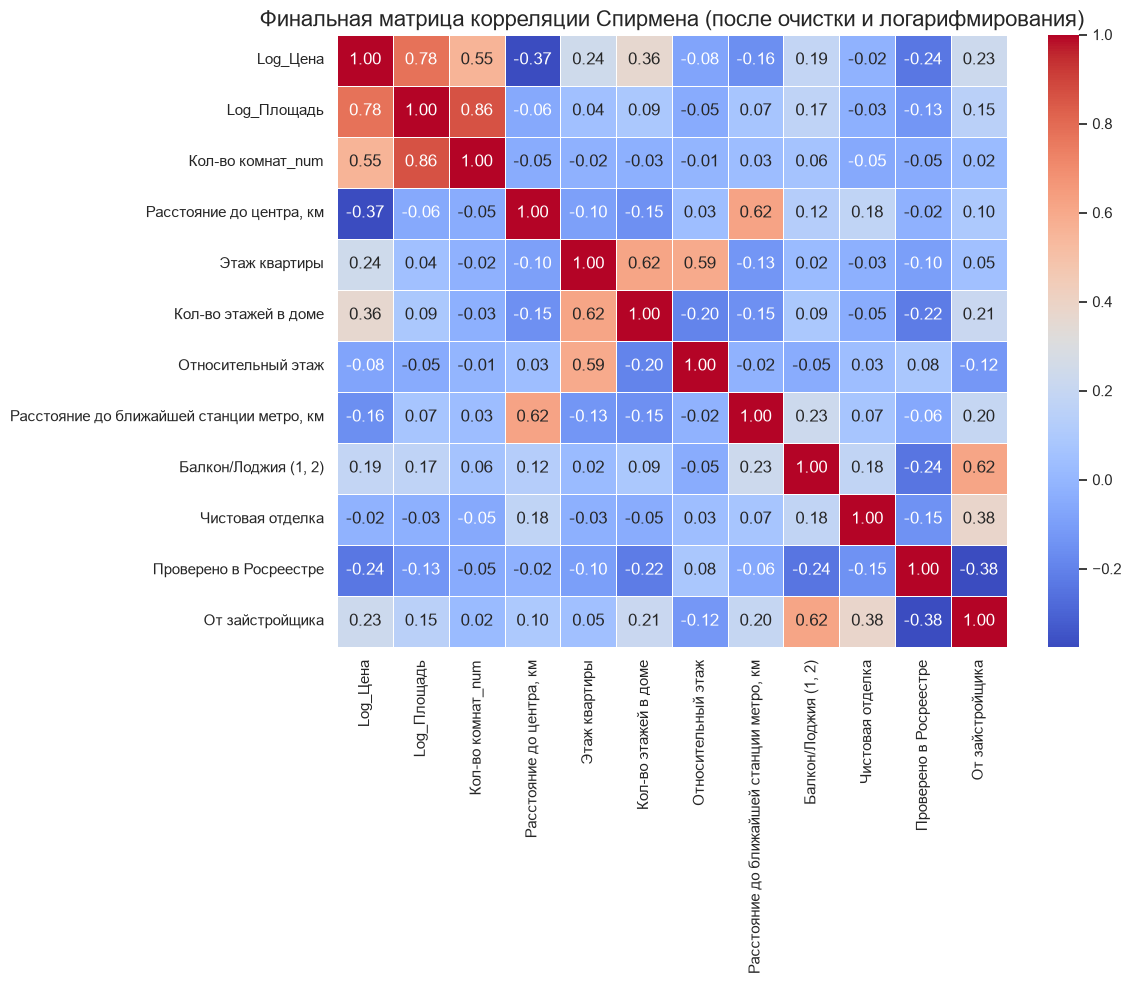

In [9]:
# РАНГОВАЯ корреляция Спирмена

# Считаем матрицу корреляции Пирсона
corr_matrix_spearman = df_encoded[corr_cols].corr(method='spearman')

# Строим красивый Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_spearman, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Финальная матрица корреляции Спирмена (после очистки и логарифмирования)", fontsize=16)
plt.tight_layout()
plt.show()

**Вывод по матрицам корреляций: сильная связь между данными, связанными с этажами, между количеством комнат и площадью, расстоянием до ближайшего метро и до центра. Эти данные следует обработать**

In [10]:
df = df_encoded

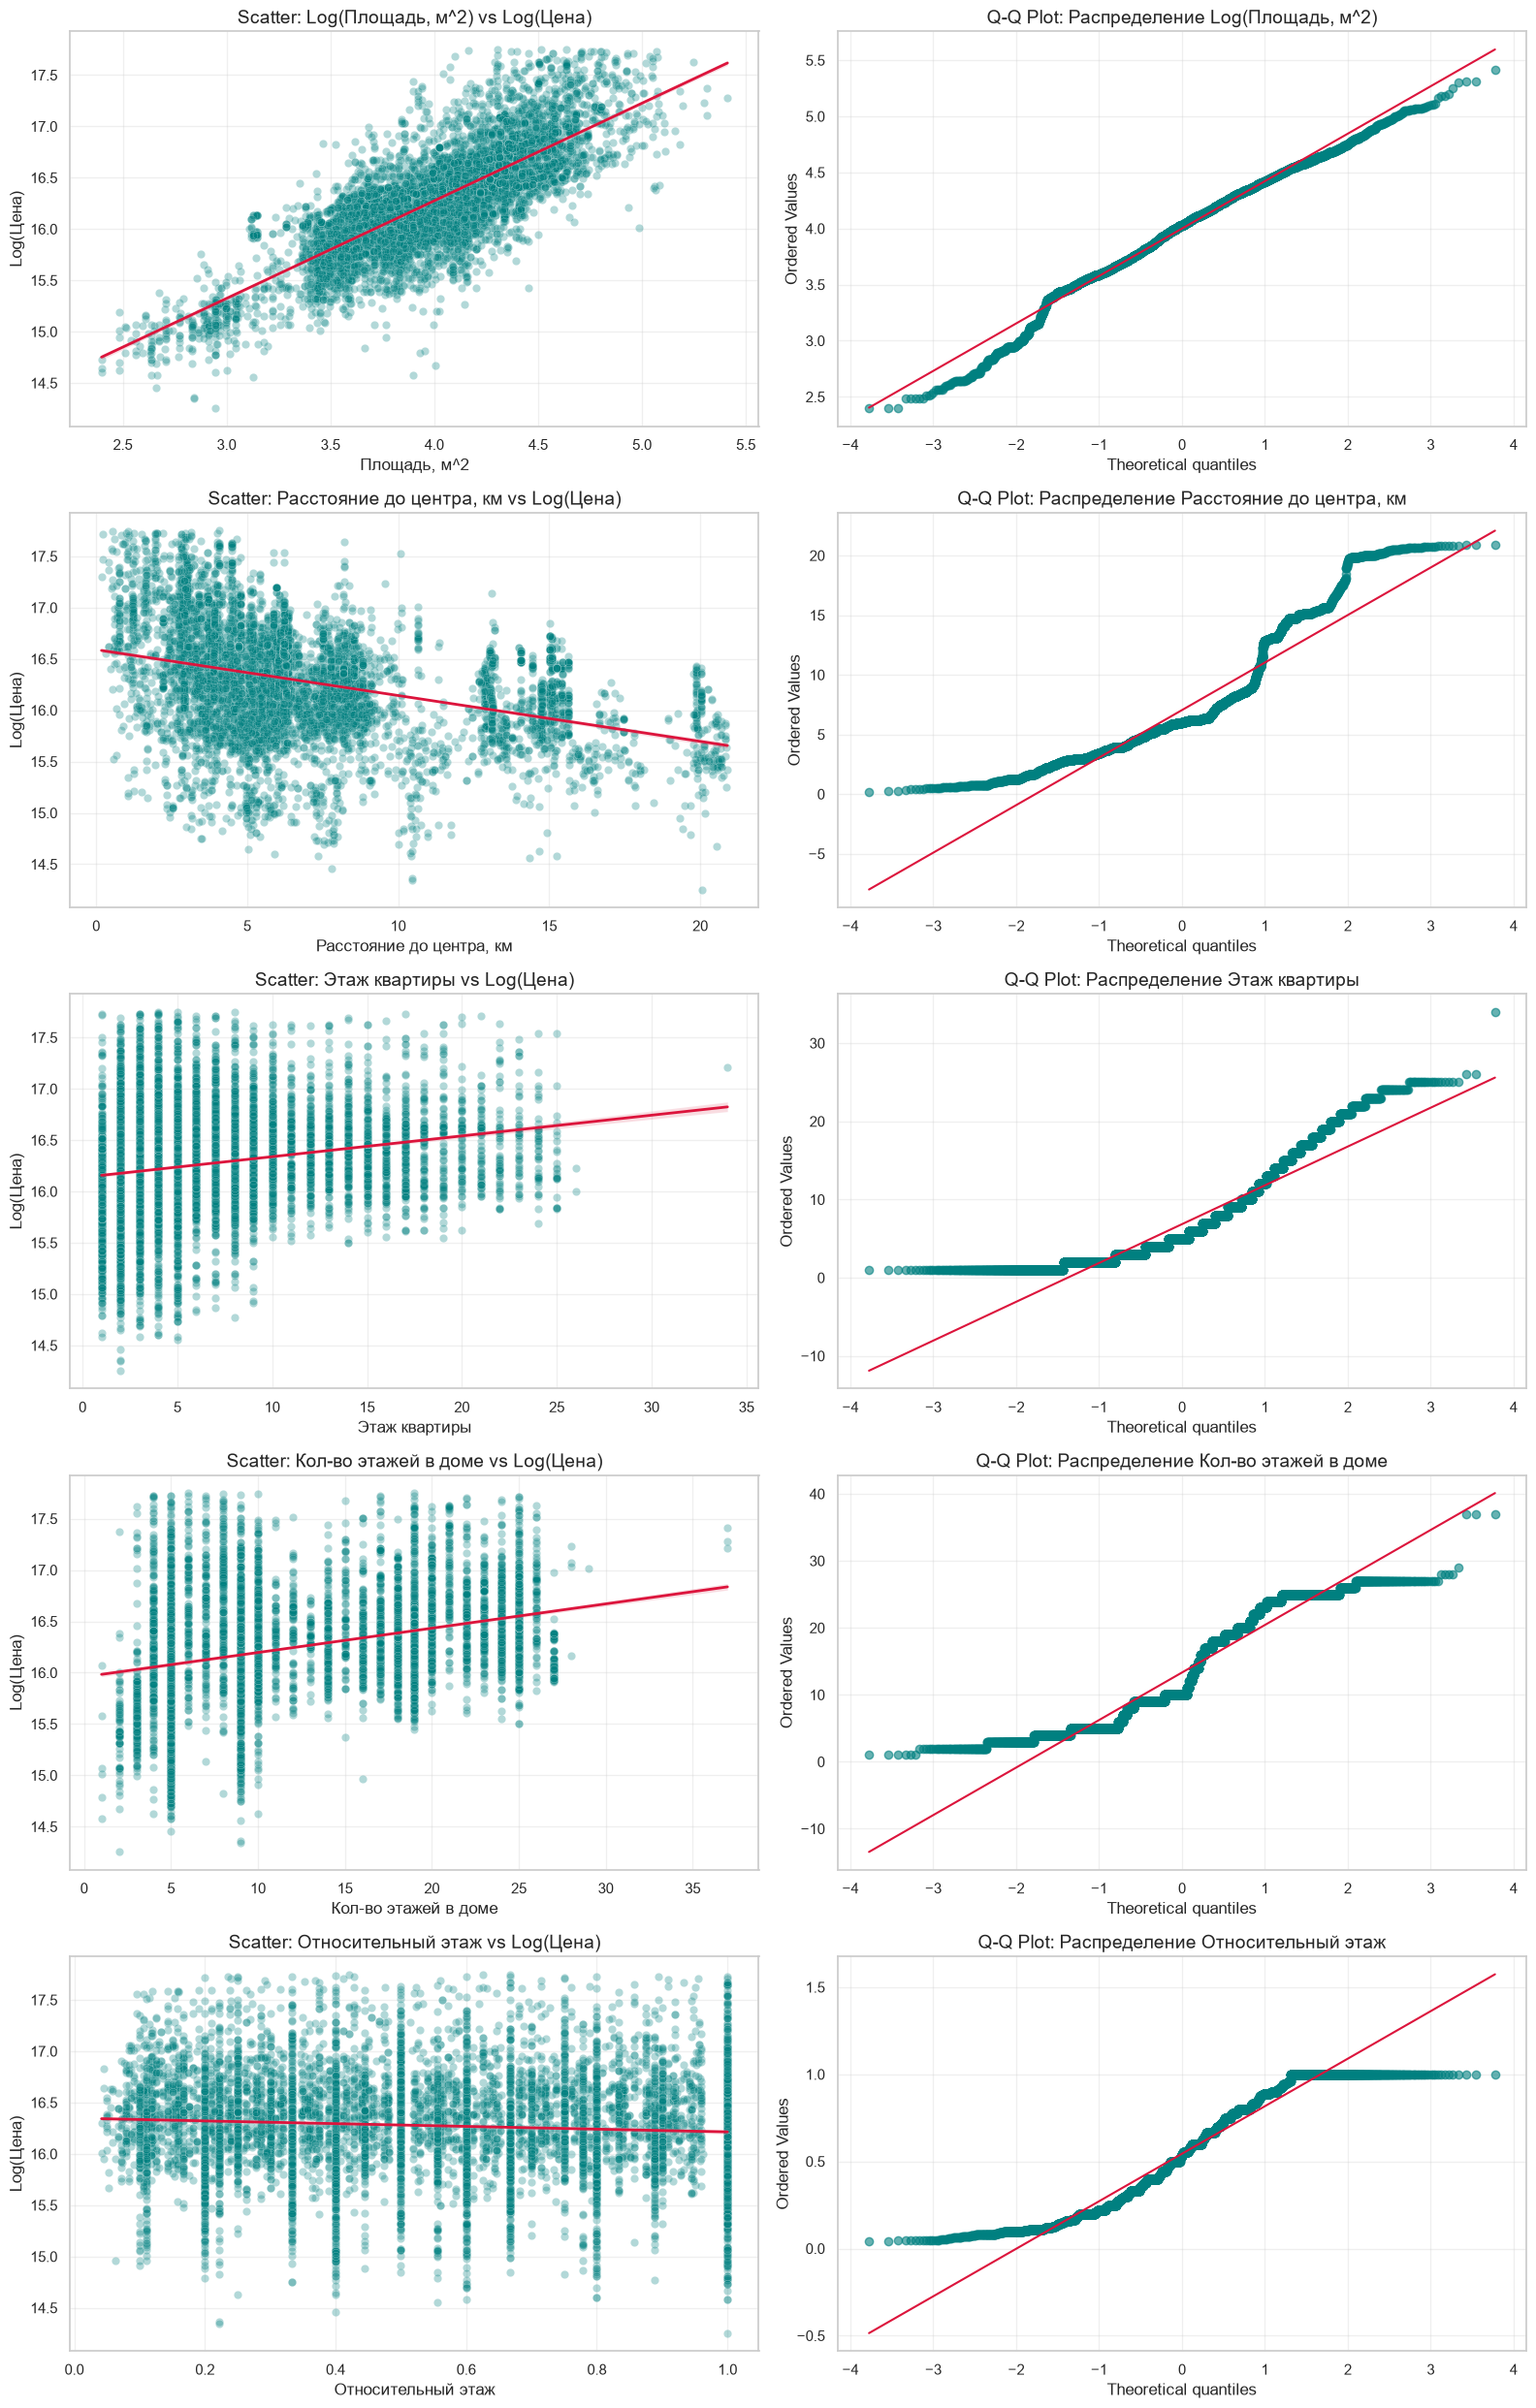

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# Берем только непрерывные числовые колонки (без флагов и категорий)
num_cols_to_plot = [
    'Площадь, м^2', 'Расстояние до центра, км',
    'Этаж квартиры', 'Кол-во этажей в доме', 'Относительный этаж'
]

# Создаем большую сетку графиков: строк столько же, сколько признаков
fig, axes = plt.subplots(nrows=len(num_cols_to_plot), ncols=2, figsize=(16, 5 * len(num_cols_to_plot)))

for i, col in enumerate(num_cols_to_plot):
    # Если это площадь, берем логарифм (мы уже знаем, что так лучше)
    # Для остальных берем чистые значения, чтобы искать скрытые изгибы
    x_data = np.log1p(df[col]) if col == 'Площадь, м^2' else df[col]
    x_label = f'Log({col})' if col == 'Площадь, м^2' else col

    # 1. Scatter Plot
    sns.regplot(
        data=df,
        x=x_data,
        y=np.log1p(df['Цена']), # Целевая переменная всегда в логарифме
        ax=axes[i, 0],
        color='teal',
        scatter_kws={'alpha': 0.3, 'edgecolor': 'w', 'linewidths': 0.3},
        line_kws={'color': 'crimson', 'lw': 2}
    )
    axes[i, 0].set_title(f'Scatter: {x_label} vs Log(Цена)', fontsize=14)
    axes[i, 0].set_ylabel('Log(Цена)')
    axes[i, 0].grid(True, alpha=0.3)

    # 2. Q-Q Plot для самого признака
    stats.probplot(x_data, dist=stats.norm, plot=axes[i, 1])
    axes[i, 1].get_lines()[0].set_color('teal')
    axes[i, 1].get_lines()[0].set_alpha(0.6)
    axes[i, 1].get_lines()[1].set_color('crimson')
    axes[i, 1].set_title(f'Q-Q Plot: Распределение {x_label}', fontsize=14)
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

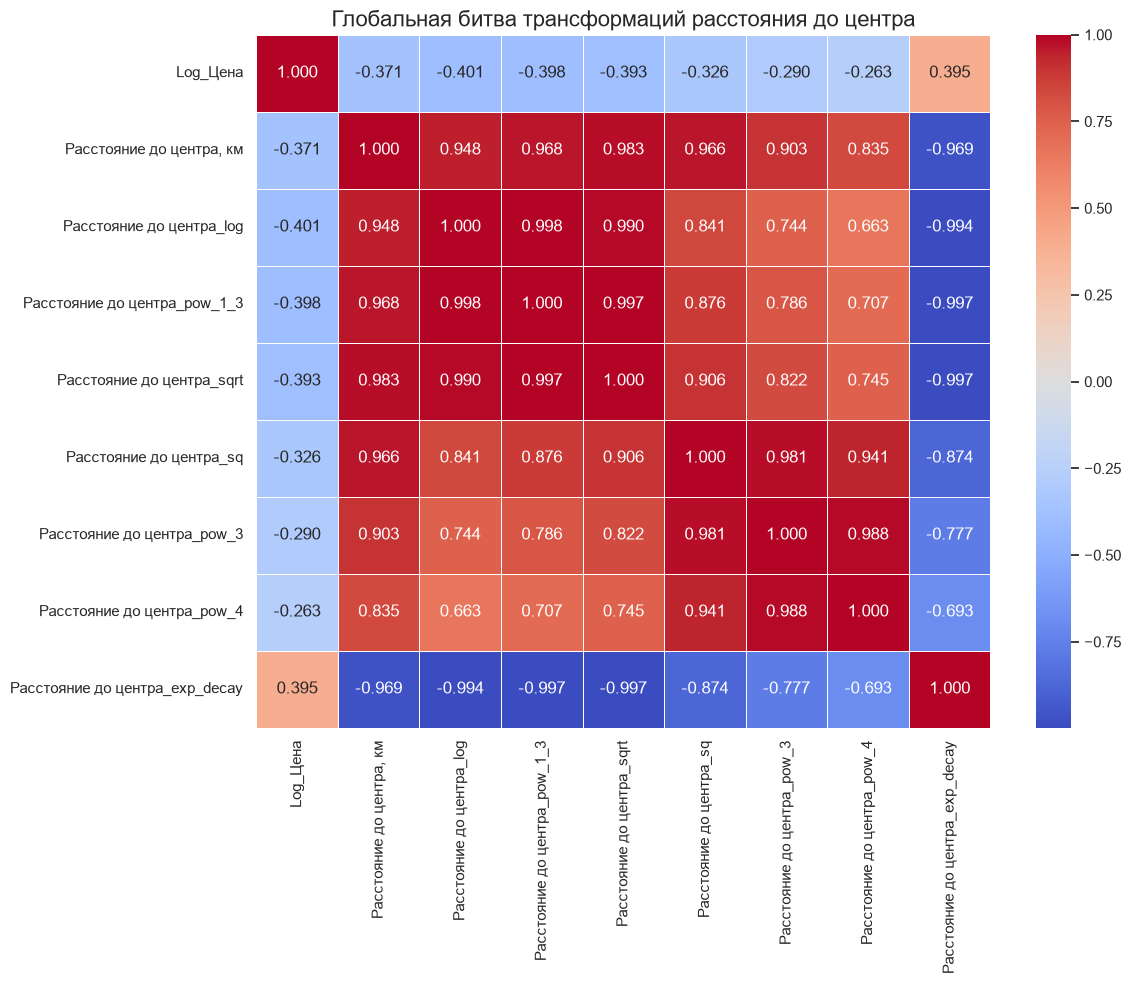

In [12]:
# эксперименты над признаками, трансформация расстояния до центра для выявления нелинейной зависимости

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Делаем копию датасета
df_exp = df.copy()
df_exp['Log_Цена'] = np.log1p(df_exp['Цена'])

# --- Базовые признаки ---
df_exp['Расстояние до центра_sq'] = df_exp['Расстояние до центра, км'] ** 2
df_exp['Расстояние до центра_sqrt'] = np.sqrt(df_exp['Расстояние до центра, км'])

# --- Твои новые идеи ---
# 1. Логарифм (добавляем 1, чтобы избежать log(0) если есть квартиры в самом центре)
df_exp['Расстояние до центра_log'] = np.log1p(df_exp['Расстояние до центра, км'])

# 2. Дробные степени (Кубический корень)
df_exp['Расстояние до центра_pow_1_3'] = df_exp['Расстояние до центра, км'] ** (1/3)

# 3. Высокие степени
df_exp['Расстояние до центра_pow_3'] = df_exp['Расстояние до центра, км'] ** 3
df_exp['Расстояние до центра_pow_4'] = df_exp['Расстояние до центра, км'] ** 4

# 4. Экспоненциальное затухание (используем минус, так как цена ПАДАЕТ при удалении)
# Делим на 10, чтобы масштаб расстояния (0-20 км) не превратил экспоненту в микроскопические числа
df_exp['Расстояние до центра_exp_decay'] = np.exp(-df_exp['Расстояние до центра, км'] / 10)


# Собираем всех кандидатов в один список
extended_test_cols = [
    'Log_Цена',
    'Расстояние до центра, км',
    'Расстояние до центра_log',
    'Расстояние до центра_pow_1_3',
    'Расстояние до центра_sqrt',
    'Расстояние до центра_sq',
    'Расстояние до центра_pow_3',
    'Расстояние до центра_pow_4',
    'Расстояние до центра_exp_decay'
]

# Считаем матрицу Пирсона
corr_extended = df_exp[extended_test_cols].corr()

# Строим хитмап
plt.figure(figsize=(12, 10))
sns.heatmap(corr_extended, annot=True, fmt=".3f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Глобальная битва трансформаций расстояния до центра", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\farha\AppData\Local\Temp\ipykernel_15772\1942571086.py:66: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\farha\PycharmProjects\AvitoParser\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


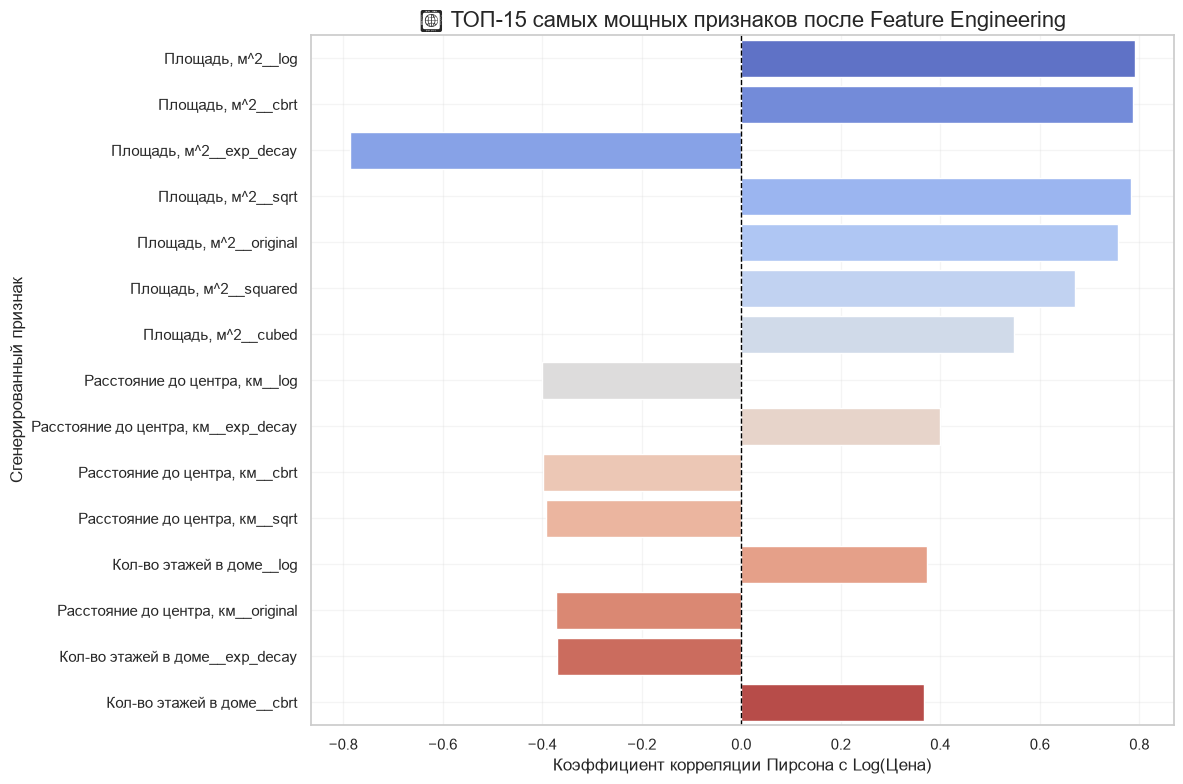

                Признак и Трансформация  Корреляция (r)  Модуль связи (|r|)
0                     Площадь, м^2__log        0.790891            0.790891
1                    Площадь, м^2__cbrt        0.787399            0.787399
2               Площадь, м^2__exp_decay       -0.786737            0.786737
3                    Площадь, м^2__sqrt        0.782632            0.782632
4                Площадь, м^2__original        0.757984            0.757984
5                 Площадь, м^2__squared        0.670689            0.670689
6                   Площадь, м^2__cubed        0.547338            0.547338
7         Расстояние до центра, км__log       -0.400682            0.400682
8   Расстояние до центра, км__exp_decay        0.399417            0.399417
9        Расстояние до центра, км__cbrt       -0.397727            0.397727
10       Расстояние до центра, км__sqrt       -0.392721            0.392721
11            Кол-во этажей в доме__log        0.373553            0.373553
12   Расстоя

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Готовим базовый датасет
df_sweep = pd.DataFrame()
df_sweep['Log_Цена'] = np.log1p(df['Цена'])

# Список всех непрерывных числовых признаков
features_to_sweep = [
    'Площадь, м^2',
    'Расстояние до центра, км',
    'Этаж квартиры',
    'Кол-во этажей в доме',
    'Относительный этаж'
]

# 2. Циклом генерируем все возможные трансформации
for col in features_to_sweep:
    # Базовые значения (оригинал)
    df_sweep[f'{col}__original'] = df[col]

    # Логарифм и корни (сглаживание больших значений)
    df_sweep[f'{col}__log'] = np.log1p(df[col])
    df_sweep[f'{col}__sqrt'] = np.sqrt(df[col])
    df_sweep[f'{col}__cbrt'] = df[col] ** (1/3)

    # Степени (усиление контраста больших значений)
    df_sweep[f'{col}__squared'] = df[col] ** 2
    df_sweep[f'{col}__cubed'] = df[col] ** 3

    # Экспоненциальное затухание (адаптируем масштаб под каждый признак)
    max_val = df[col].max()
    if max_val > 0:
        df_sweep[f'{col}__exp_decay'] = np.exp(-df[col] / (max_val / 3))

# 3. Считаем корреляцию Пирсона только относительно Log_Цена
corr_with_target = df_sweep.corr()['Log_Цена'].drop('Log_Цена')

# 4. Собираем результаты в красивую таблицу-лидерборд
leaderboard = pd.DataFrame({
    'Признак и Трансформация': corr_with_target.index,
    'Корреляция (r)': corr_with_target.values,
    'Модуль связи (|r|)': corr_with_target.abs().values
})

# Сортируем по силе влияния
leaderboard = leaderboard.sort_values(by='Модуль связи (|r|)', ascending=False).reset_index(drop=True)

# 5. Визуализируем ТОП-15 лучших трансформаций
plt.figure(figsize=(12, 8))
sns.barplot(
    data=leaderboard.head(15),
    x='Корреляция (r)',
    y='Признак и Трансформация',
    palette='coolwarm',
    hue='Признак и Трансформация',
    legend=False
)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('🏆 ТОП-15 самых мощных признаков после Feature Engineering', fontsize=16)
plt.xlabel('Коэффициент корреляции Пирсона с Log(Цена)', fontsize=12)
plt.ylabel('Сгенерированный признак', fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Выводим текстовый топ для детального изучения
print(leaderboard.head(20))

**Исходя из этих графиков видно, более сильными признаками являются: логарифмированная площадь и экспонированное растояние до центра**

**Также исходя из scatter и Q-Q графиков видны распределения данных относительно нормального распределения. В целях улучшения модели мы удалим признак "Этаж квартиры" и "Относительый этаж", добавив метки "первый этаж" и "последний этаж"**

In [14]:
df_orig.columns

Index(['Кол-во комнат', 'Площадь, м^2', 'Этаж квартиры',
       'Кол-во этажей в доме', 'Относительный этаж',
       'Расстояние до центра, км', 'Ближайшая станция метро',
       'Расстояние до ближайшей станции метро, км', 'Балкон/Лоджия (1, 2)',
       'Чистовая отделка', 'Проверено в Росреестре', 'От зайстройщика',
       'Цена'],
      dtype='str')

In [22]:
import numpy as np
import pandas as pd

def pipeline_feature_engineering_final(df_raw):
    df = df_raw.copy()

    # 1. ТРАНСФОРМАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
    if 'Цена' in df.columns:
        df['Log_Цена'] = np.log1p(df['Цена'])
        df = df.drop(columns=['Цена'])

    # 2. МАТЕМАТИЧЕСКИЕ ТРАНСФОРМАЦИИ
    if 'Площадь, м^2' in df.columns:
        df['Log_Площадь'] = np.log1p(df['Площадь, м^2'])
    if 'Кол-во этажей в доме' in df.columns:
        df['Log_Кол_во_этажей'] = np.log1p(df['Кол-во этажей в доме'])
    if 'Расстояние до центра, км' in df.columns:
        max_dist = df['Расстояние до центра, км'].max()
        df['Близость_к_центру_exp'] = np.exp(-df['Расстояние до центра, км'] / (max_dist / 3))

    # 3. ПСИХОЛОГИЯ ЭТАЖНОСТИ (Флаги)
    if 'Этаж квартиры' in df.columns and 'Кол-во этажей в доме' in df.columns:
        df['is_first_floor'] = (df['Этаж квартиры'] == 1).astype(int)
        df['is_last_floor'] = (df['Этаж квартиры'] == df['Кол-во этажей в доме']).astype(int)

    # 4. УМНЫЙ ЭНКОДИНГ БАЛКОНОВ (Дропаем именно 'Нет')
    if 'Балкон/Лоджия (1, 2)' in df.columns:
        df['Балкон/Лоджия'] = pd.Categorical(
            df['Балкон/Лоджия (1, 2)'].map({0: 'Нет', 1: 'Балкон', 2: 'Лоджия'}),
            categories=['Нет', 'Балкон', 'Лоджия'],
            ordered=True
        )

    # 5. ЗАЧИСТКА ХВОСТОВ (Метро НЕ трогаем, оно пойдет на энкодинг)
    columns_to_drop = [
        'Площадь, м^2',
        'Расстояние до центра, км',
        'Кол-во этажей в доме',
        'Этаж квартиры',
        'Относительный этаж',
        'Балкон/Лоджия (1, 2)',
        'Расстояние до ближайшей станции метро, км'
    ]

    existing_drops = [col for col in columns_to_drop if col in df.columns]
    df = df.drop(columns=existing_drops)

    # Полностью удаляем всё, что связано с количеством комнат (и числовую, и дамми, если были)
    room_cols = [col for col in df.columns if 'Кол-во комнат' in col]
    df = df.drop(columns=room_cols)

    # 6. ФИНАЛЬНЫЙ ЭНКОДИНГ (Сюда красиво залетят Станции метро и Балконы)
    categorical_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
    if categorical_cols:
        df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

    return df

# Прогоняем заново
df_ready = pipeline_feature_engineering_final(df)

In [26]:
# Берём случайные 1000 квартир
df_sample_1k = df.sample(n=1000, random_state=42)
df_sample_3k = df.sample(n=3000, random_state=67)
df_sample_5k = df.sample(n=5000, random_state=68)
df_sample_all = df

# Сохраняем отдельно
df_sample_1k.to_csv('dataset_sample_1000.csv', index=False)
df_sample_3k.to_csv('dataset_sample_3000.csv', index=False)
df_sample_5k.to_csv('dataset_sample_5000.csv', index=False)
df_sample_all.to_csv('dataset_sample_all.csv', index=False)

print('Готово!')

Готово!
